In [ ]:
"""
Implementation of Parallelized Extreme Learning Machine (P-ELM)
Target: Online Data Classification & DevOps Anomaly Detection

Author: Amanda Taheri
Based on the research paper:
Title: Parallelized Extreme Learning Machine for Online Data Classification
https://doi.org/10.1007/s10489-022-03308-7
Copyright (c) 2026. All rights reserved.

"""

In [14]:
import pandas as pd
import numpy as np
import os
import sys
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Add src to path to import our modules
sys.path.append(os.path.abspath(os.path.join('..')))
from src.elm_online import OnlineParallelELM

# Define the local path to the dataset
file_path = '../data/kddcup.data_10_percent.gz'

# Column names for KDD Cup 99 dataset
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
           "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in", 
           "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", 
           "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", 
           "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", 
           "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", 
           "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
           "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", 
           "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", 
           "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print("Loading dataset from local storage...")
df = pd.read_csv(file_path, compression='gzip', header=None, names=columns)

# Encoding categorical features (Strings -> Numbers)
le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    df[col] = le.fit_transform(df[col])

# Binary Classification: normal. is 0, everything else (attacks) is 1
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)

X = df.drop('label', axis=1).values.astype(float)
y = df['label'].values

print(f"Dataset Loaded: {X.shape[0]} samples with {X.shape[1]} features.")
print(f"Class Distribution: Normal: {np.sum(y==0)}, Anomalies: {np.sum(y==1)}")

# Train-Test Split (60% for training/initialization, 40% for streaming test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Loading dataset from local storage...
Dataset Loaded: 494021 samples with 41 features.
Class Distribution: Normal: 97278, Anomalies: 396743


In [15]:
# Initialize the Online Parallel ELM
# input_size = 41 (KDD features), hidden_size = 1000 for high capacity
model = OnlineParallelELM(input_size=X_train_scaled.shape[1], hidden_size=1000, n_workers=4)

# We simulate a stream by processing the test set in chunks
batch_size = 5000
n_samples = len(X_test_scaled)
chunk_metrics = []

print(f"Starting Online Learning on {n_samples} samples...")

for i in range(0, n_samples, batch_size):
    X_batch = X_test_scaled[i : i + batch_size]
    y_batch = y_test[i : i + batch_size]
    
    # Learn from the current batch (Parallel processing + Weight Synthesis)
    model.learn_batch(X_batch, y_batch)
    
    # Evaluate current performance
    preds = (model.predict(X_batch) > 0.5).astype(int)
    acc = accuracy_score(y_batch, preds)
    chunk_metrics.append(acc)
    
    if i % 20000 == 0:
        print(f"Processed {i}/{n_samples} samples... Current Batch Accuracy: {acc:.4f}")

print("Online Training Completed.")


Starting Online Learning on 197609 samples...
Processed 0/197609 samples... Current Batch Accuracy: 0.9886
Processed 20000/197609 samples... Current Batch Accuracy: 0.9776
Processed 40000/197609 samples... Current Batch Accuracy: 0.9812
Processed 60000/197609 samples... Current Batch Accuracy: 0.9772
Processed 80000/197609 samples... Current Batch Accuracy: 0.9814
Processed 100000/197609 samples... Current Batch Accuracy: 0.9804
Processed 120000/197609 samples... Current Batch Accuracy: 0.9818
Processed 140000/197609 samples... Current Batch Accuracy: 0.9806
Processed 160000/197609 samples... Current Batch Accuracy: 0.9812
Processed 180000/197609 samples... Current Batch Accuracy: 0.9846
Online Training Completed.



 FINAL PERFORMANCE REPORT (Real DevOps Data):
-------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     38977
     Anomaly       0.99      0.99      0.99    158632

    accuracy                           0.98    197609
   macro avg       0.97      0.97      0.97    197609
weighted avg       0.98      0.98      0.98    197609



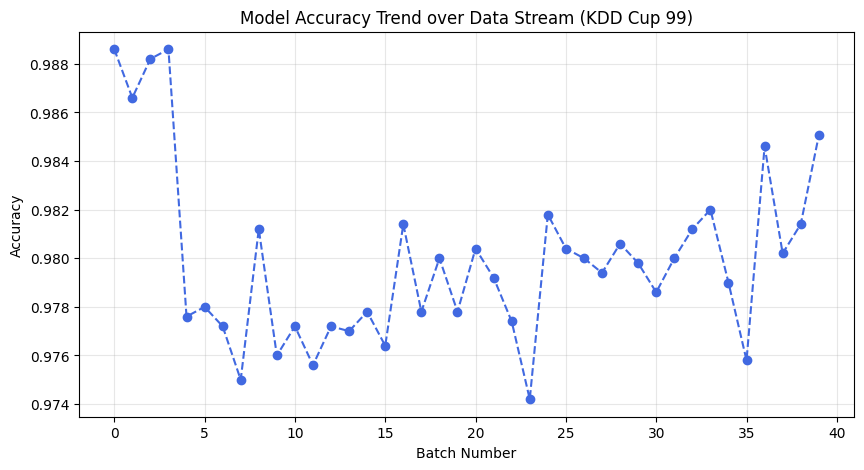

In [16]:
# Predict on the entire test set
final_preds_raw = model.predict(X_test_scaled)
final_preds = (final_preds_raw > 0.5).astype(int)

print("\n FINAL PERFORMANCE REPORT (Real DevOps Data):")
print("-" * 55)
print(classification_report(y_test, final_preds, target_names=['Normal', 'Anomaly']))

# Visualize Accuracy Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(chunk_metrics, marker='o', color='royalblue', linestyle='--')
plt.title('Model Accuracy Trend over Data Stream (KDD Cup 99)')
plt.xlabel('Batch Number')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.show()
